# Heart Disease Risk Prediction using Logistic Regression

## Nicolás Toro Criollo

---

### Introducción

BLA BLA BLA [Cambiarlo]

### 1. Imports

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 2. Dataset

In [118]:
df = pd.read_csv('heart.csv')

df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### 3. Exploratory Data Analysis

We initialy are going to explore the dataset to understand the features and their relationships with the target variable. This will help us identify any patterns or trends that may be useful for our logistic regression model.

**Key Variable Distribution**

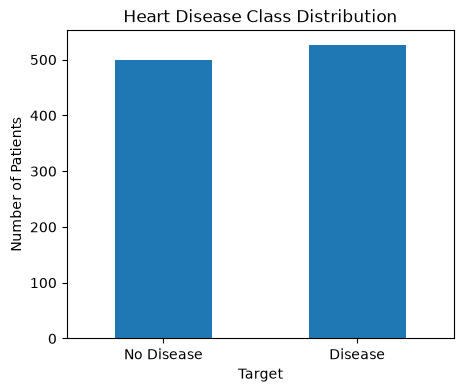

In [119]:
df["target"].value_counts()

plt.figure(figsize=(5,4))
df["target"].value_counts().sort_index().plot(kind="bar")

plt.title("Heart Disease Class Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.xticks([0,1], ["No Disease","Disease"], rotation=0)

plt.show()

**Outliers Detection** 

C:\Users\nikot\AppData\Local\Temp\ipykernel_17424\2507574595.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=True)
C:\Users\nikot\AppData\Local\Temp\ipykernel_17424\2507574595.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=True)
C:\Users\nikot\AppData\Local\Temp\ipykernel_17424\2507574595.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=True)
C:\Users\nikot\AppData\Local\Temp\ipykernel_17424\2507574595.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'}

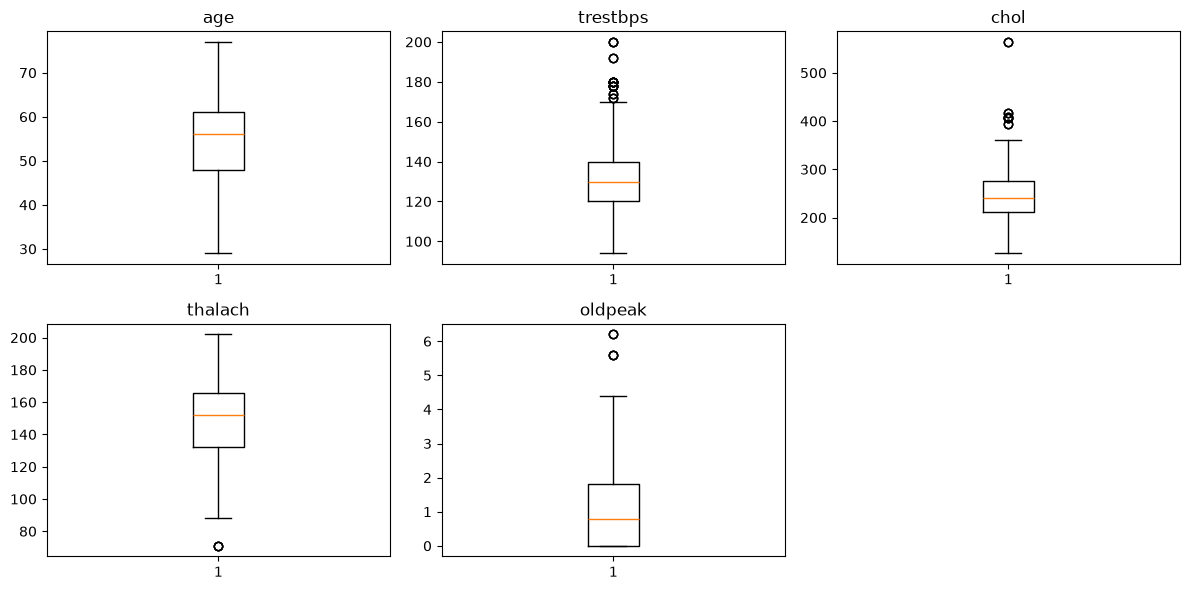

In [120]:
features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

plt.figure(figsize=(12,6))

for i, feature in enumerate(features):
    plt.subplot(2,3,i+1)
    plt.boxplot(df[feature], vert=True)
    plt.title(feature)

plt.tight_layout()
plt.show()

**Outlier Analysis**
 
Boxplots were generated for the main numerical variables.

Several potential outliers were identified in resting blood pressure, cholesterol, and ST depression (oldpeak). Since this dataset contains real clinical measurements, these values are considered medically plausible rather than data entry errors.

Therefore, no observations were removed. Instead, feature normalization will be applied before training the Logistic Regression model.

**Target variable verification**

In [121]:
df["target"].unique()

array([0, 1])

Due to the nature of the dataset, the target variable is binary, so its inncesary to do steps like one-hot encoding or label encoding. The target variable is already in a suitable format for logistic regression.

**Class distribution**

It's important to do a class distribution analysis to understand the balance of the target variable. This will help us determine if any techniques, such as oversampling or undersampling, are needed to address class imbalance before training the model.

Class Distribution:
target
0    499
1    526
Name: count, dtype: int64
Class Distribution (Percentage):
target
0    48.68
1    51.32
Name: count, dtype: float64


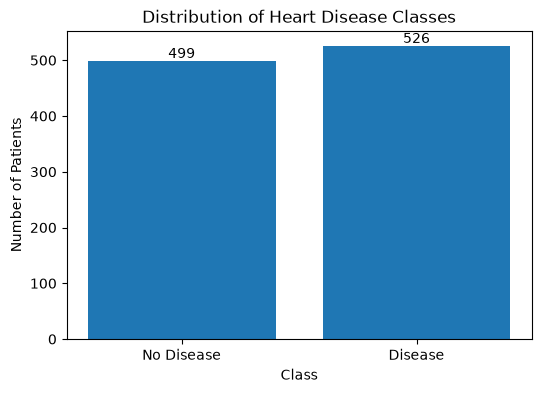

In [122]:
class_distribution = df["target"].value_counts().sort_index()

print("Class Distribution:" )
print(class_distribution) 

print("Class Distribution (Percentage):" )
print((class_distribution / len(df) * 100).round(2))

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["No Disease", "Disease"],
    class_distribution.values
)

plt.title("Distribution of Heart Disease Classes")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

# Mostrar valores encima de cada barra
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha='center'
    )

plt.show()

The target variable was inspected to verify its encoding before model training.

The dataset already provides a binary target variable:

- **0:** No heart disease
- **1:** Presence of heart disease

Therefore, no additional binarization was required.

The class distribution shows:

| Class | Patients | Percentage |
|------|---------:|-----------:|
| No Disease | 499 | 48.68% |
| Disease | 526 | 51.32% |

The dataset is well balanced, with only a small difference between both classes. Consequently, no resampling techniques were required, and a stratified train-test split will be used to preserve this distribution in both subsets.


### 4. Data preprocesing

According to intructions, sex clinical variable were selected for training the model. The rest of the features were discarded:

- Age (`age`)
- Resting blood pressure (`trestbps`)
- Serum cholesterol (`chol`)
- Maximum heart rate achieved (`thalach`)
- ST depression induced by exercise (`oldpeak`)
- Number of major vessels colored by fluoroscopy (`ca`)

These variables are impotant for the model providing relevant information about the patient's health status and risk factors for heart disease.

In [123]:
selected_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

X = df[selected_features]
y = df["target"]

print("Selected Features:")
print(X.head())

Selected Features:
   age  trestbps  chol  thalach  oldpeak  ca
0   52       125   212      168      1.0   2
1   53       140   203      155      3.1   0
2   70       145   174      125      2.6   0
3   61       148   203      161      0.0   1
4   62       138   294      106      1.9   3


**Train/Test Split**

The dataset was first separated by class, each subset was randomly shuffled, and a 70/30 partition was applied independently. Finally, both classes were merged and shuffled again to produce the final training and testing datasets.

This approach preserves the original class distribution while avoiding the use of external data splitting utilities.

In [124]:
# Separar registros por clase
class_0 = df[df["target"] == 0]
class_1 = df[df["target"] == 1]

# Mezclar los registros de cada clase para evitar sesgos
np.random.seed(42)

class_0 = class_0.sample(frac=1, random_state=42).reset_index(drop=True)
class_1 = class_1.sample(frac=1, random_state=42).reset_index(drop=True)

# Calcular el tamaño del entrenamiento
train_size_0 = int(0.7 * int(len(class_0)))
train_size_1 = int(0.7 * int(len(class_1)))

# Dividir en conjuntos de entrenamiento y prueba
train_0 = class_0.iloc[:train_size_0]
test_0 = class_0.iloc[train_size_0:]

train_1 = class_1.iloc[:train_size_1]
test_1 = class_1.iloc[train_size_1:]

# Unir los conjuntos de entrenamiento y prueba
train_df = pd.concat([train_0, train_1])
test_df = pd.concat([test_0, test_1])

# Mezclar los conjuntos de entrenamiento y prueba
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Separar variables y etiquetas
X_train = train_df[selected_features]
y_train = train_df["target"]

X_test = test_df[selected_features]
y_test = test_df["target"]

# Verificación
print("Training set:", len(train_df))
print("Test set:", len(test_df))

print("\nTraining distribution")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting distribution")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set: 717
Test set: 308

Training distribution
target
1    51.32
0    48.68
Name: proportion, dtype: float64

Testing distribution
target
1    51.3
0    48.7
Name: proportion, dtype: float64


**Normalization**

It's important to normalize the features before training the logistic regression model because they have different scales and units. Normalization ensures that all features contribute equally to the model's learning process, preventing any single feature from dominating the others due to its scale.

In [125]:
# Calcular la media del entrenamiento
train_mean = np.mean(X_train, axis=0)

# Calcular la desviación estándar del entrenamiento
train_std = np.std(X_train, axis=0)

# Evitar división por cero
train_std = np.where(train_std == 0, 1, train_std)

# Normalizar los datos de entrenamiento
X_train_norm = (X_train - train_mean) / train_std

# Normalizar los datos de prueba
X_test_norm = (X_test - train_mean) / train_std

# Verificación de la normalización
print("Training Mean:")
print(np.round(np.mean(X_train_norm, axis=0), 5))

print("\nTraining Standard Deviation:")
print(np.round(np.std(X_train_norm, axis=0), 5))

Training Mean:
age         0.0
trestbps    0.0
chol        0.0
thalach    -0.0
oldpeak    -0.0
ca          0.0
dtype: float64

Training Standard Deviation:
age         1.0
trestbps    1.0
chol        1.0
thalach     1.0
oldpeak     1.0
ca          1.0
dtype: float64


### 5. Logistic Regression Implementation

Before training the Logisic Model, we need the dataset in the correct format. Thats why we will convert the DataFrames from Pandas to Numpy arrays. This will allow us to perform matrix operations more efficiently during the training process. 

In [126]:
X_train = X_train_norm.to_numpy()
X_test = X_test_norm.to_numpy()

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)

print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train:  (717, 6)
y_train:  (717,)
X_test:  (308, 6)
y_test:  (308,)


**Sigmoid Function Implmentation**

The sigmoid function transforms the linear combination of the input features into a probability between 0 and 1.

It is defined as:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

where $$z = Xw + b$$

A value close to 1 indicates a high probability of heart disease, while a value close to 0 indicates a low probability.

Parameters:

* z (float or numpy array) : Input value(s).

Returns:

* numpy array : The sigmoid of the input value(s).

In [127]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

**Test of the Sigmoid Function**

In [128]:
test_values = np.array([-10, -2, 0, 2, 10])

print("Sigmoid Function Test:")
print(sigmoid(test_values))

Sigmoid Function Test:
[4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]


**Function Visualization**

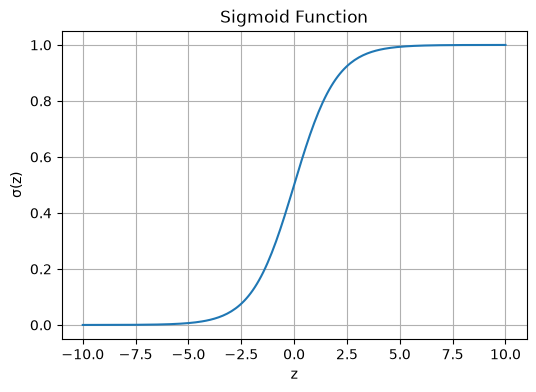

In [129]:
x = np.linspace(-10, 10, 200)
y = sigmoid(x)

plt.figure(figsize=(6,4))
plt.plot(x, y)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.grid(True)
plt.show()

**Binary Cross-Entropy Loss Function Implementation**

To evaluate the quality of the predictions, Binary Cross-Entropy (BCE) was implemented as the loss function.

Unlike Mean Squared Error, BCE is specifically designed for binary classification problems and provides better optimization behavior when combined with the sigmoid activation function.

An epsilon value was used to avoid numerical issues caused by computing the logarithm of zero.

Before training, the model parameters were initialized to zero, producing an initial cost close to 0.693. This value corresponds to a classifier that predicts a probability of 0.5 for every observation.

Parameters:

* X (numpy array): Feature Matrix.
* y (numpy array): True labels.
* w (numpy array): Weights.
* b (float): Bias.

Returns:

* float: The computed binary cross-entropy loss.

In [130]:
def compute_cost(X, y, w, b):

    # Número de ejemplos
    m = X.shape[0]

    # Combinacion lineal
    z = np.dot(X, w) + b

    # Aplicación de la función sigmoide
    y_hat = sigmoid(z)

    # Estabilidad numerica
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

    # Cálculo del costo usando la función de pérdida logarítmica
    cost = -np.sum( y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat )) / m
    
    return cost

**Test Cost Function**

In [131]:
w = np.zeros(X_train.shape[1])
b = 0

initial_cost = compute_cost(
    X_train,
    y_train,
    w,
    b
)

print(initial_cost)

0.6931471805599454


**Gradient Computation**

To optimize the Logistic Regression model, the gradients of the Binary Cross-Entropy loss with respect to the model parameters were implemented manually.

For each iteration, the prediction error is computed as:

$$
\hat{y} - y
$$

The gradients are then calculated as:

- **Weights**

$$
dw=\frac{1}{m}X^T(\hat y-y)
$$

- **Bias**

$$
db=\frac{1}{m}\sum(\hat y-y)
$$

These gradients indicate how each parameter should be updated to minimize the loss function during Gradient Descent.

Parameters:

* X (ndarray): Feature matrix.
* y (ndarray): True labels.
* w (ndarray): Model weights.
* b (float): Bias term.

Returns
* dw (ndarray): Gradient with respect to weights.
* db (float): Gradient with respect to bias.

In [132]:
def compute_gradients(X, y, w, b):

    # Número de ejemplos
    m = X.shape[0]

    # Combinacion lineal
    z = np.dot(X, w) + b

    # Aplicación de la función sigmoide
    y_hat = sigmoid(z)

    # Error
    error = y_hat - y

    # Cálculo de los gradientes
    dw = (1 / m) * np.dot(X.T, error)
    db = (1 / m) * np.sum(error)

    return dw, db

**Test**

In [133]:
w = np.zeros(X_train.shape[1])
b = 0

dw, db = compute_gradients(X_train, y_train, w, b)

print("Gradient dw:", dw)
print("\nGradient db:", db)
print("\nGradient dw shape:", dw.shape)

Gradient dw: [ 0.12676362  0.09669794  0.06287603 -0.20556055  0.21172901  0.17630173]

Gradient db: -0.013249651324965132

Gradient dw shape: (6,)


**Gradient Descent Implementation**

Gradient Descent was implemented to iteratively optimize the Logistic Regression parameters.

The model parameters were initialized to zero and updated according to:

$$
w := w - \alpha dw
$$

$$
b := b - \alpha db
$$

where α represents the learning rate.

The cost value was stored after each iteration to monitor the convergence of the optimization process. As expected, the Binary Cross-Entropy loss decreased progressively during training, indicating that the model successfully learned the relationship between the selected clinical features and the target variable.

In [134]:
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):

    # Número de características
    n = X.shape[1]

    # Inicialización de parámetros
    w = np.zeros(n)
    b = 0

    # Lista para almacenar el costo en cada iteración
    cost_history = []

    for i in range(iterations):
        # Cálculo de gradientes
        dw, db = compute_gradients(X, y, w, b)

        # Actualización de parámetros
        w -= learning_rate * dw
        b -= learning_rate * db

        # Cálculo del costo
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        # Impresión del costo cada 100 iteraciones
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost}")

    return w, b, cost_history

**Test**

In [135]:
learning_rate = 0.01
iterations = 1000

w, b, cost_history = gradient_descent(
    X_train,
    y_train,
    learning_rate,
    iterations
)

print("Starting Gradient Descent...")
print("Final Cost:", cost_history[-1])

Iteration 0: Cost 0.6916735176619201
Iteration 100: Cost 0.5957862590539205
Iteration 200: Cost 0.5539953445519288
Iteration 300: Cost 0.5327404086492208


Iteration 400: Cost 0.5205281568330034
Iteration 500: Cost 0.5128625874404711
Iteration 600: Cost 0.5077287329996301
Iteration 700: Cost 0.5041195897057451
Iteration 800: Cost 0.5014868195510356
Iteration 900: Cost 0.4995105926082852
Starting Gradient Descent...
Final Cost: 0.4980069287180807


**Visualization**

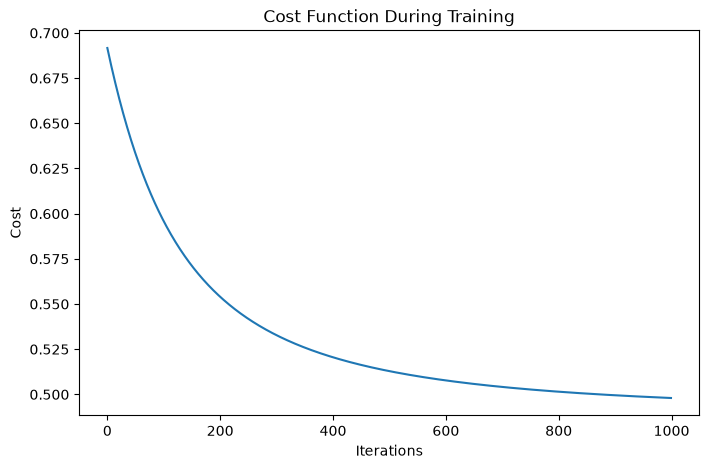

In [136]:
plt.figure(figsize=(8,5))

plt.plot(cost_history)

plt.title("Cost Function During Training")
plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.show()

plt.show()

### 6. Model Training and Evaluation

Due the nature of the dataset, the dataset as itself dont have probabilities, so we need to trasnform that probabilities into binary values to evaluate the model's performance. A threshold of 0.5 was used, meaning that if the predicted probability is greater than or equal to 0.5, the model predicts the presence of heart disease (1), otherwise it predicts no heart disease (0).

Parameters:

* X (ndarray): Feature matrix.
* w (ndarray): Model weights.
* b (float): Bias term.
* threshold (float): Decision threshold for binary classification.

Returns:

* predictions (ndarray): Binary predictions based on the threshold.

In [137]:
def predict(X, w, b, threshold=0.5):

    z = np.dot(X, w) + b

    probabilities = sigmoid(z)

    predictions = (probabilities >= threshold).astype(int)

    return predictions

**Test**

In [138]:
y_train_pred = predict(X_train, w, b)
y_test_pred = predict(X_test, w, b)

print("Training Predictions:", y_train_pred[:10])

Training Predictions: [1 0 0 1 1 1 0 1 0 1]


After the predicions, the ollowing metrics were computed to evaluate the model's performance:

* Accuracy
* Precision
* Recall
* F1-Score

Additionally, a confusion matrix was generated to visualize the model's performance in terms of true positives, true negatives, false positives, and false negatives.

**Accuracy Evaluation**

In [139]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

**Confusion Matrix**

Before we implement Precision, Recall and F1-Score, we need to compute the confusion matrix. The confusion matrix is a useful tool for evaluating the performance of a classification model, as it provides a summary of the true positive, true negative, false positive, and false negative predictions.

In [140]:
def confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    return tp, tn, fp, fn

**Test**

In [141]:
tp, tn, fp, fn = confusion_matrix(y_test, y_test_pred)

print(tp, tn, fp, fn)

129 105 45 29


**Precision, Recall and F1-Score**

In [143]:
def precision(pt, fp):
    return tp / (tp + fp)

def recall(tp, fn):
    return tp / (tp + fn)

def f1_score(precision, recall):
    return 2 * (precision * recall) / (precision + recall)

tp, tn, fp, fn = confusion_matrix(
    y_test,
    y_test_pred
)

acc = accuracy(
    y_test,
    y_test_pred
)

prec = precision(tp, fp)

rec = recall(tp, fn)

f1 = f1_score(prec, rec)

**Visualization**

In [144]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        acc,
        prec,
        rec,
        f1
    ]
})

results

,Metric,Value
0,Accuracy,0.759740
1,Precision,0.741379
2,Recall,0.816456
3,F1-Score,0.777108


### 7. Decision Boundary

### 8. Regularization

### 9. SageMaker

### 10. Conclusions